# 00 - Photometry Dataset Design Audit

This notebook audits the Phase 2 dataset design. The source of truth is `configs/filters.yaml`; the notebook compares the configured `strict` and `relaxed` photometric families across the configured astrometric subsets.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import yaml

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT / 'src'))

with (ROOT / 'configs/filters.yaml').open(encoding='utf-8') as fh:
    filters = yaml.safe_load(fh)
with (ROOT / filters['paths_config']).open(encoding='utf-8') as fh:
    paths = yaml.safe_load(fh)

ref_dir = ROOT / paths['processed_reference_dir']
neg_dir = ROOT / paths['processed_simbad_negative_dir']
variants = filters['color_locus']['dataset_variants']
family_order = list(filters['photometry']['families'])
subset_order = ['photometry', 'parallax_soft', 'poe_1', 'poe_2', 'poe_3', 'poe_5']


def split_variant_name(variant):
    for family in family_order:
        prefix = f'{family}_'
        if variant.startswith(prefix):
            return family, variant[len(prefix):]
    return 'legacy', variant


def variant_metadata(variant):
    family, subset = split_variant_name(variant)
    return {'dataset_variant': variant, 'dataset_family': family, 'astrometric_subset': subset}


def ordered_summary(df):
    out = df.copy()
    out['dataset_family'] = pd.Categorical(out['dataset_family'], family_order, ordered=True)
    out['astrometric_subset'] = pd.Categorical(out['astrometric_subset'], subset_order, ordered=True)
    return out.sort_values(['dataset_family', 'astrometric_subset']).reset_index(drop=True)

from wr_detector.features import load_reference_feature_frame, make_dataset_variants

DB_PATH = ROOT / paths['wr_reference_db']
full = load_reference_feature_frame(DB_PATH)
configured_variants = make_dataset_variants(full, filters)
len(full), list(configured_variants)

(442,
 ['strict_photometry',
  'strict_parallax_soft',
  'strict_poe_1',
  'strict_poe_2',
  'strict_poe_3',
  'strict_poe_5',
  'relaxed_photometry',
  'relaxed_parallax_soft',
  'relaxed_poe_1',
  'relaxed_poe_2',
  'relaxed_poe_3',
  'relaxed_poe_5'])

## Configured Dataset Matrix

In [2]:
summary_rows = []
for variant, frame in configured_variants.items():
    meta = variant_metadata(variant)
    summary_rows.append({
        **meta,
        'rows': len(frame),
        'retention_vs_reference': len(frame) / len(full),
        'median_parallax': frame['parallax'].median(),
        'median_parallax_over_error': frame['parallax_over_error'].median(),
    })
summary = ordered_summary(pd.DataFrame(summary_rows))
summary

,dataset_variant,dataset_family,astrometric_subset,rows,retention_vs_reference,median_parallax,median_parallax_over_error
0,strict_photometry,strict,photometry,306,0.692308,0.158196,4.715608
1,strict_parallax_soft,strict,parallax_soft,259,0.585973,0.187075,6.109190
2,strict_poe_1,strict,poe_1,222,0.502262,0.198043,7.824076
3,strict_poe_2,strict,poe_2,200,0.452489,0.202592,9.304933
4,strict_poe_3,strict,poe_3,181,0.409502,0.208400,10.982916
5,strict_poe_5,strict,poe_5,146,0.330317,0.219140,12.468990
6,relaxed_photometry,relaxed,photometry,347,0.785068,0.171364,5.667342
7,relaxed_parallax_soft,relaxed,parallax_soft,298,0.674208,0.201564,7.026629
8,relaxed_poe_1,relaxed,poe_1,261,0.590498,0.209785,9.159730
9,relaxed_poe_2,relaxed,poe_2,237,0.536199,0.215859,10.681320


In [3]:
summary.pivot(index='astrometric_subset', columns='dataset_family', values='rows').loc[subset_order]

dataset_family,strict,relaxed
astrometric_subset,,
photometry,306,347
parallax_soft,259,298
poe_1,222,261
poe_2,200,237
poe_3,181,218
poe_5,146,179


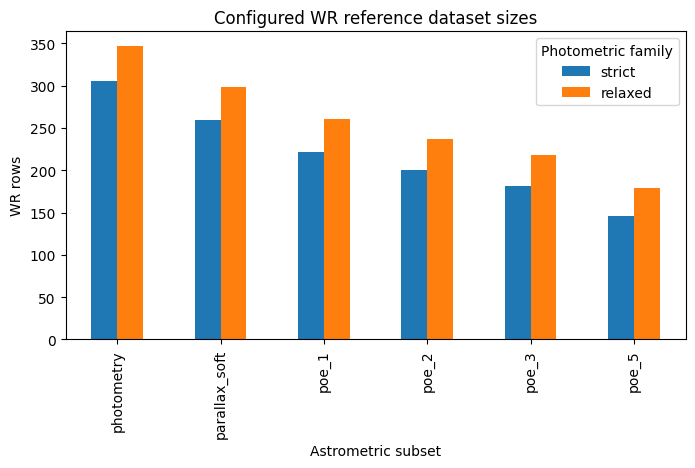

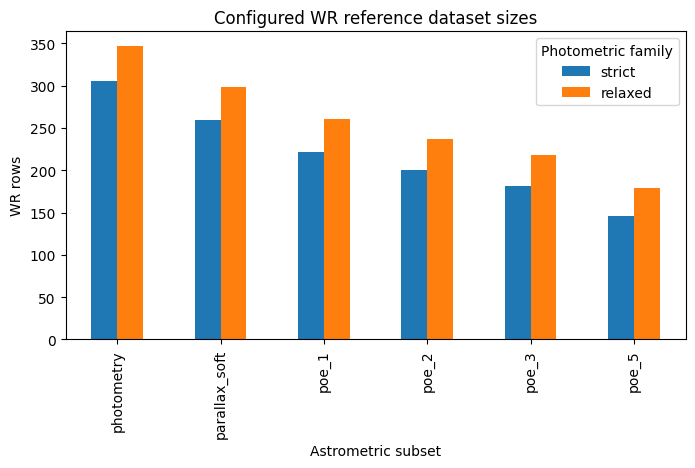

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
plot_data = summary.pivot(index='astrometric_subset', columns='dataset_family', values='rows').loc[subset_order]
plot_data.plot(kind='bar', ax=ax)
ax.set_xlabel('Astrometric subset')
ax.set_ylabel('WR rows')
ax.set_title('Configured WR reference dataset sizes')
ax.legend(title='Photometric family')
fig

## Quality Flag Inventory

In [5]:
required_2mass = ['J', 'H', 'Ks']
required_wise = ['W1', 'W2']
quality_rows = []
for band, pos in zip(required_2mass, range(3)):
    counts = full['tmass_quality'].astype('string').str[pos].value_counts(dropna=False)
    for quality, rows in counts.items():
        quality_rows.append({'mission': '2MASS', 'band': band, 'quality': quality, 'rows': int(rows)})
for band, pos in zip(required_wise, range(2)):
    counts = full['wise_quality'].astype('string').str[pos].value_counts(dropna=False)
    for quality, rows in counts.items():
        quality_rows.append({'mission': 'WISE', 'band': band, 'quality': quality, 'rows': int(rows)})
quality_inventory = pd.DataFrame(quality_rows).sort_values(['mission', 'band', 'quality'])
quality_inventory

,mission,band,quality,rows
5,2MASS,H,A,398
11,2MASS,H,B,1
12,2MASS,H,C,1
10,2MASS,H,D,1
6,2MASS,H,E,16
9,2MASS,H,F,2
8,2MASS,H,U,11
7,2MASS,H,NaN,12
0,2MASS,J,A,404
4,2MASS,J,B,1


## Dataset Feature Distributions

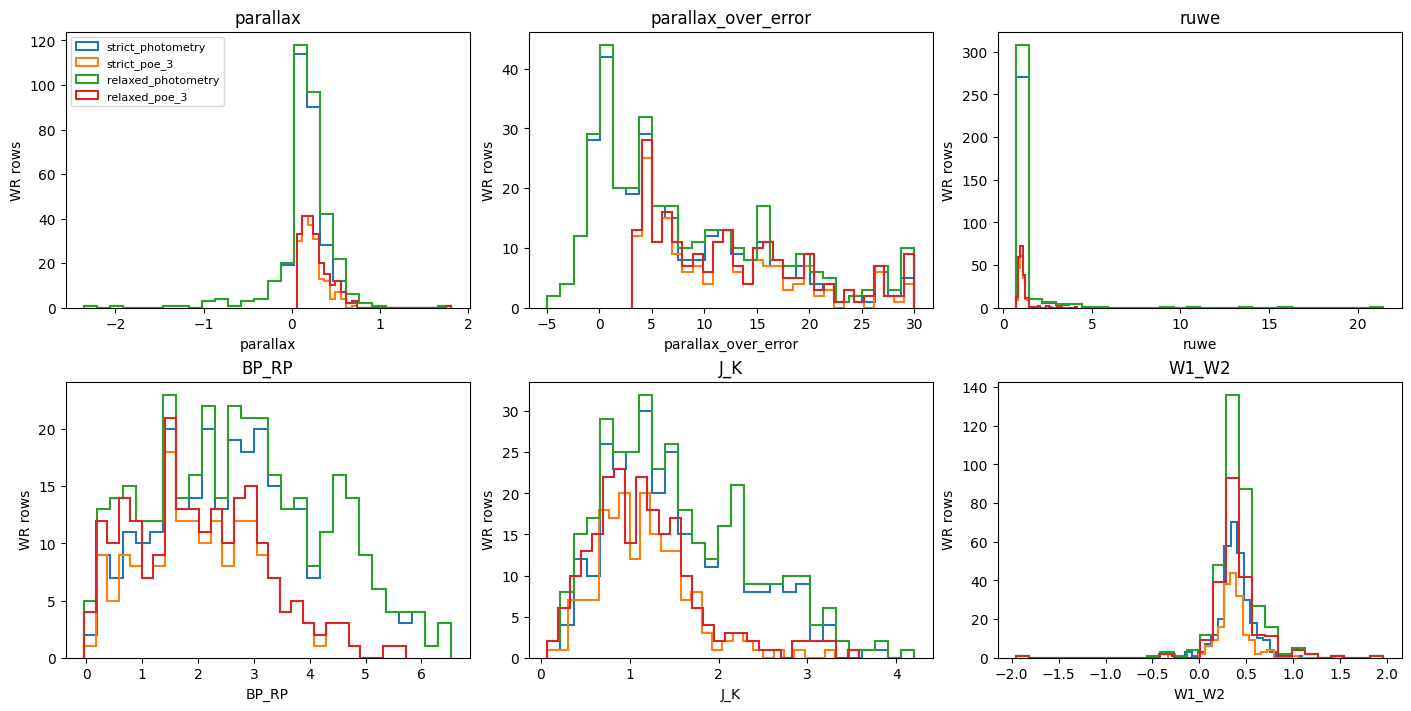

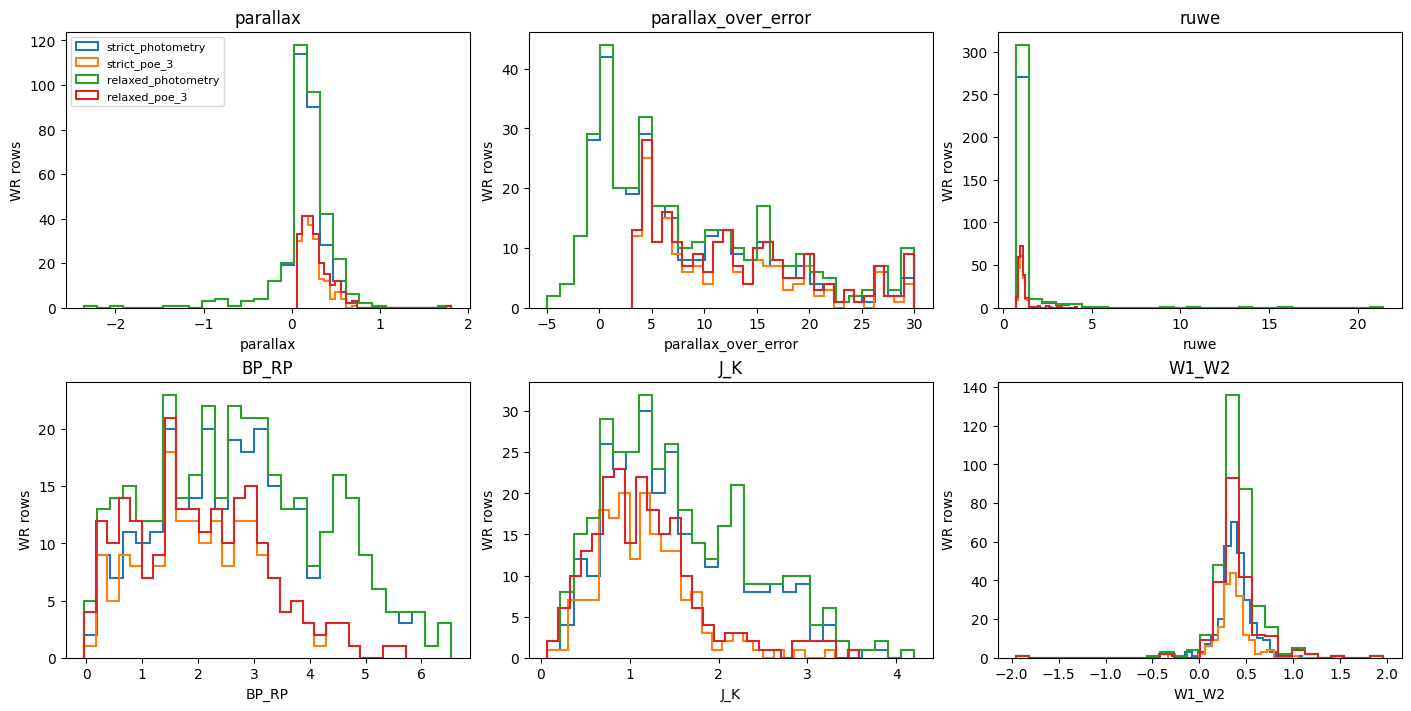

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7), constrained_layout=True)
features = ['parallax', 'parallax_over_error', 'ruwe', 'BP_RP', 'J_K', 'W1_W2']
plot_variants = [v for v in ['strict_photometry', 'strict_poe_3', 'relaxed_photometry', 'relaxed_poe_3'] if v in configured_variants]
for ax, feature in zip(axes.ravel(), features):
    for variant in plot_variants:
        frame = configured_variants[variant]
        values = frame[feature].dropna()
        if feature == 'parallax_over_error':
            values = values.clip(lower=-5, upper=30)
        ax.hist(values, bins=28, histtype='step', linewidth=1.5, label=variant)
    ax.set_title(feature)
    ax.set_xlabel(feature)
    ax.set_ylabel('WR rows')
axes[0, 0].legend(fontsize=8)
fig

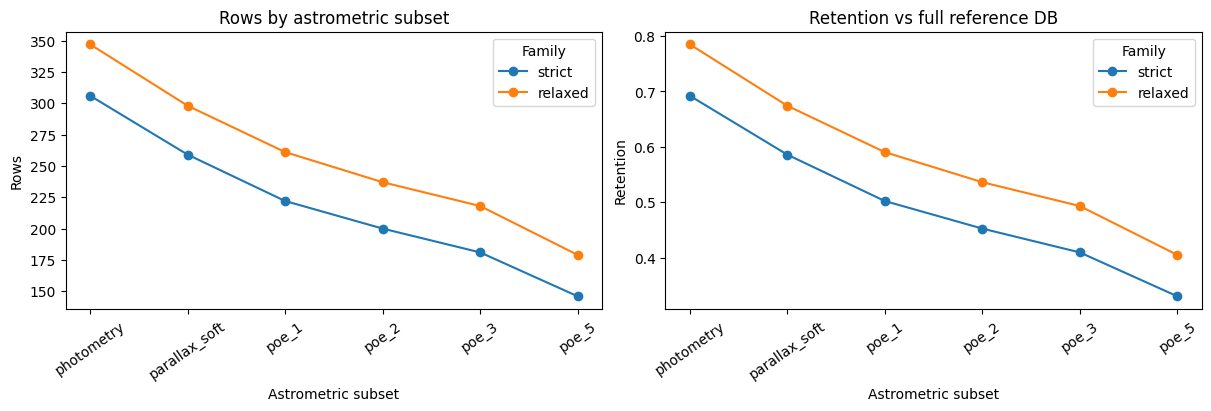

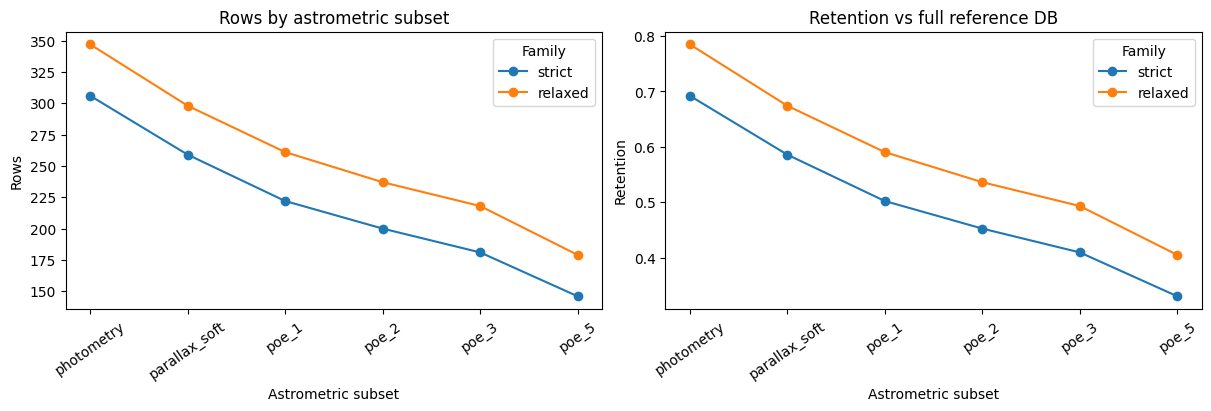

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
for family in family_order:
    family_summary = summary[summary['dataset_family'] == family]
    axes[0].plot(family_summary['astrometric_subset'].astype(str), family_summary['rows'], marker='o', label=family)
    axes[1].plot(family_summary['astrometric_subset'].astype(str), family_summary['retention_vs_reference'], marker='o', label=family)
axes[0].set_title('Rows by astrometric subset')
axes[1].set_title('Retention vs full reference DB')
for ax in axes:
    ax.set_xlabel('Astrometric subset')
    ax.tick_params(axis='x', rotation=35)
    ax.legend(title='Family')
axes[0].set_ylabel('Rows')
axes[1].set_ylabel('Retention')
fig

## Strict vs Relaxed Gain

In [8]:
gain_rows = []
for subset in subset_order:
    strict_key = f'strict_{subset}'
    relaxed_key = f'relaxed_{subset}'
    strict_ids = set(configured_variants[strict_key]['source_id'])
    relaxed_ids = set(configured_variants[relaxed_key]['source_id'])
    gain_rows.append({
        'astrometric_subset': subset,
        'strict_rows': len(strict_ids),
        'relaxed_rows': len(relaxed_ids),
        'additional_relaxed_rows': len(relaxed_ids - strict_ids),
        'strict_not_in_relaxed_rows': len(strict_ids - relaxed_ids),
    })
gain = pd.DataFrame(gain_rows)
gain

,astrometric_subset,strict_rows,relaxed_rows,additional_relaxed_rows,strict_not_in_relaxed_rows
0,photometry,306,347,41,0
1,parallax_soft,259,298,39,0
2,poe_1,222,261,39,0
3,poe_2,200,237,37,0
4,poe_3,181,218,37,0
5,poe_5,146,179,33,0


In [9]:
added_ids = set(configured_variants['relaxed_photometry']['source_id']) - set(configured_variants['strict_photometry']['source_id'])
added = full[full['source_id'].isin(added_ids)].copy()
added[['source_id', 'wr_id', 'tmass_quality', 'wise_quality', 'parallax', 'parallax_over_error']].head(25)

,source_id,wr_id,tmass_quality,wise_quality,parallax,parallax_over_error
20,454818035714964992,4,AAA,BAAA,0.355611,16.182405
21,4042922573453831936,103,AAA,BAAA,0.369601,15.215171
29,5868384073377056384,53,AAA,BAAA,0.332772,22.466219
31,5952743072247166464,90,AAA,BAAA,0.723015,26.848572
34,4053759222599074048,95,AAA,BBAA,0.434635,16.156553
43,5966563486675142912,79a,AAA,BBAA,0.541667,10.709468
44,5990124062365822592,73,AAA,BAAA,0.088761,4.300079
47,4153716198275554176,113,AAA,BBAA,0.489568,31.133715
96,4152380330315696640,114,AAA,BAAA,0.507769,20.058250
112,5254268071479968512,24,AAA,BAAU,0.366250,16.013941


## Phase 2 Decision

The configured datasets keep W3/W4 out of the required Phase 2 photometry. Phase 2 compares `strict` and `relaxed` families across `photometry`, `parallax_soft`, `poe_1`, `poe_2`, `poe_3`, and `poe_5`; model scripts should select a configured variant instead of rebuilding filters inside notebooks.